In [1]:
%run base.ipynb

mare


#### noise structure



Let's inspect a different noise structure, namely a Bernoullian one that *multiplies* the output $y$ with a small probability $1-p$, and see whether the resulting graphs change. 



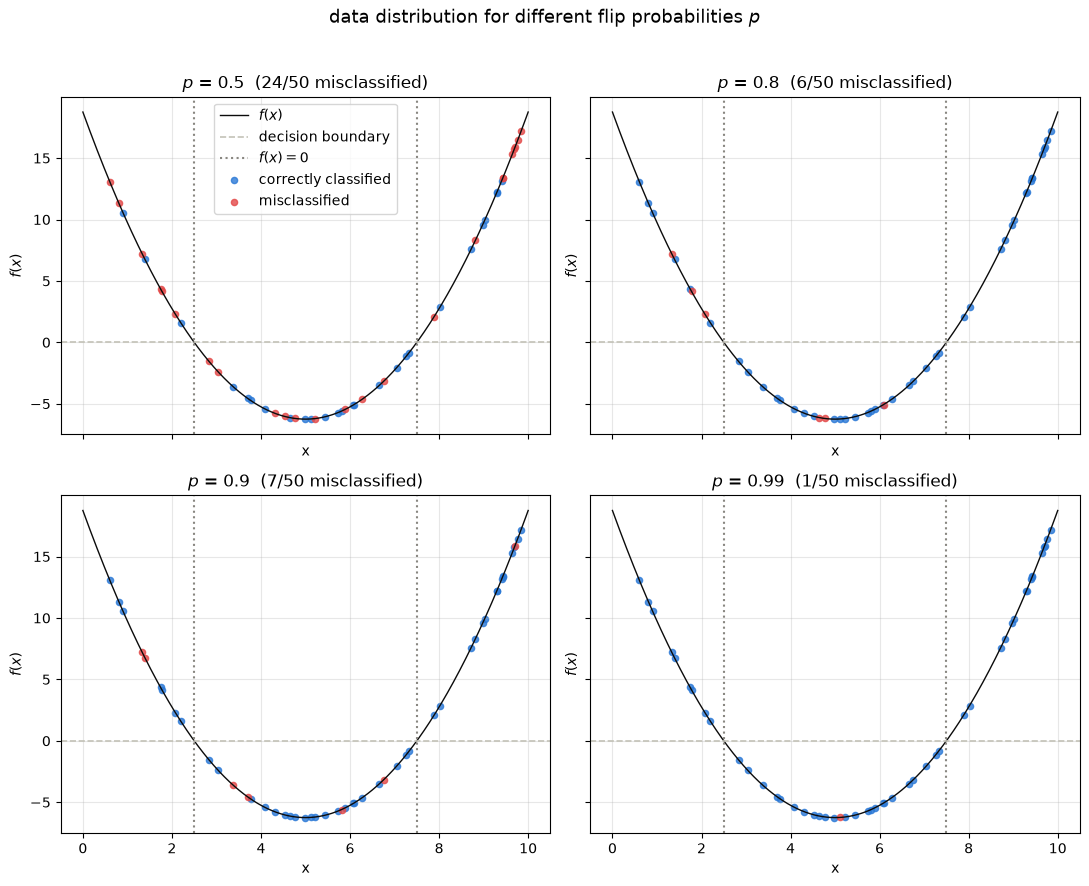

In [2]:
n = 50
N = 10_000

explore_data(fun = centered_parabola, n_train = 50, supp_size = N,
             error_type= 'bernoulli', probs = (0.5, 0.8, 0.9, 0.99) )

[checkpoint] bound: "naive" -> bound_naive, params: []


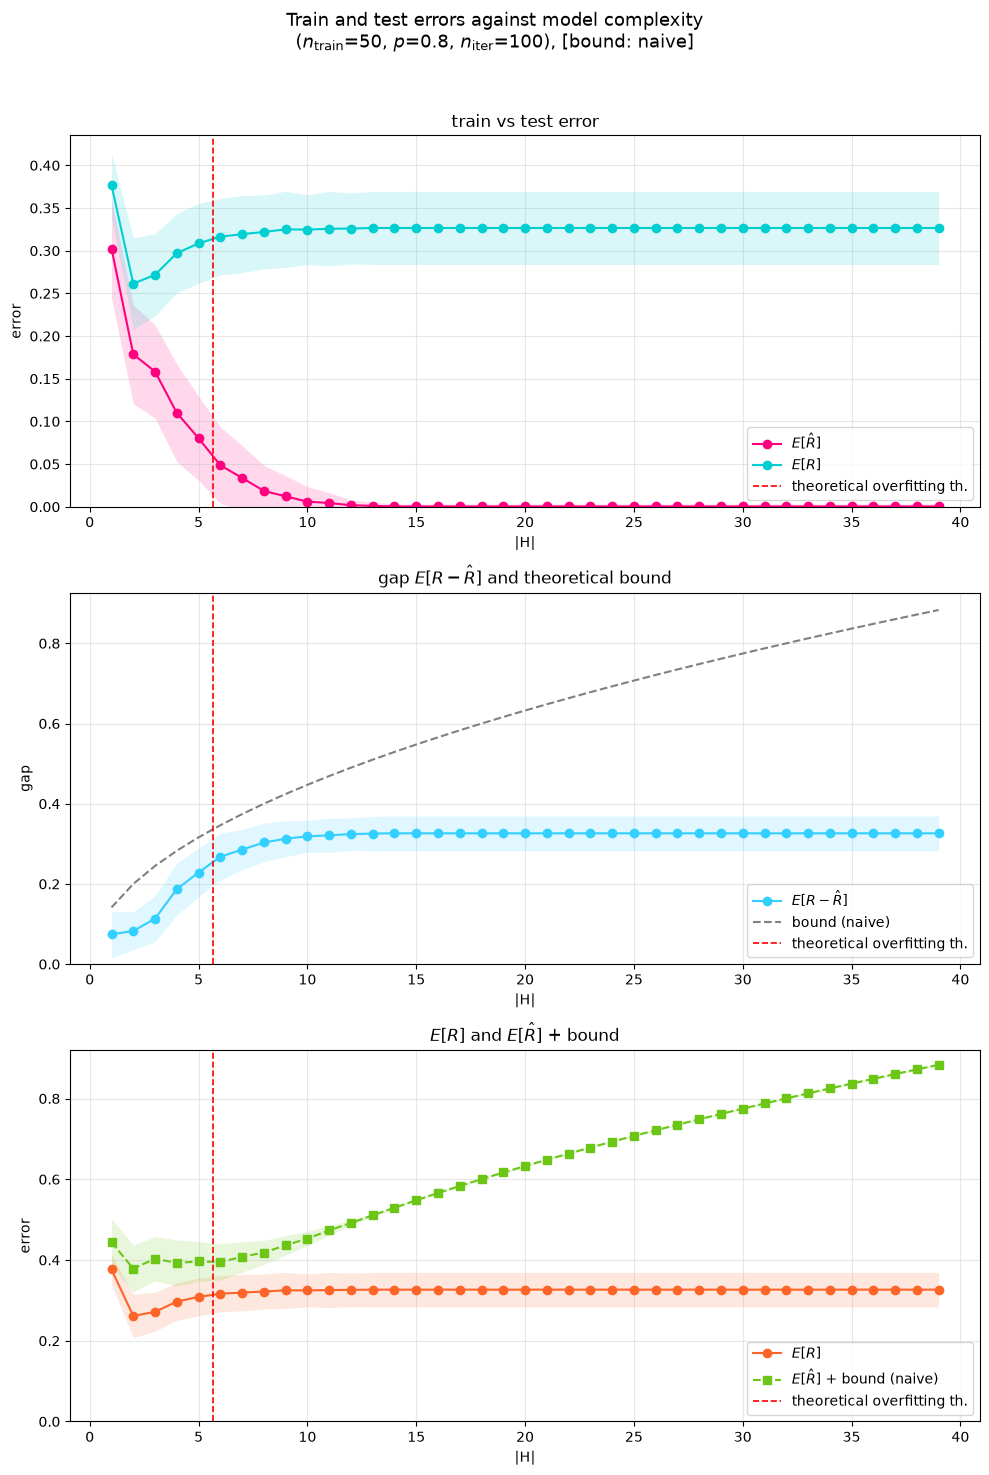

In [3]:
# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 50
noise_std = 5
prob = 0.8
T = 100

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y_bernoulli(x = x_test, f = centered_parabola, p = prob)

# build models and do plots
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel, 
    error_type= 'bernoulli', error_par=prob)
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
      n_train = n, sigma = noise_std, num_iter= T, model = mymodel, 
      bound_name = "naive", bound_params ={}, 
      error_type='bernoulli', error_par= prob)

In [4]:
# show animated function

animation = animate_learned_function(model = mymodel, n_train = n, best_pred = predictions,
                         best_x = x, best_y = y, x_grid = x_grid)
HTML(animation.to_jshtml())

[checkpoint] bound: "naive" -> bound_naive, params: []


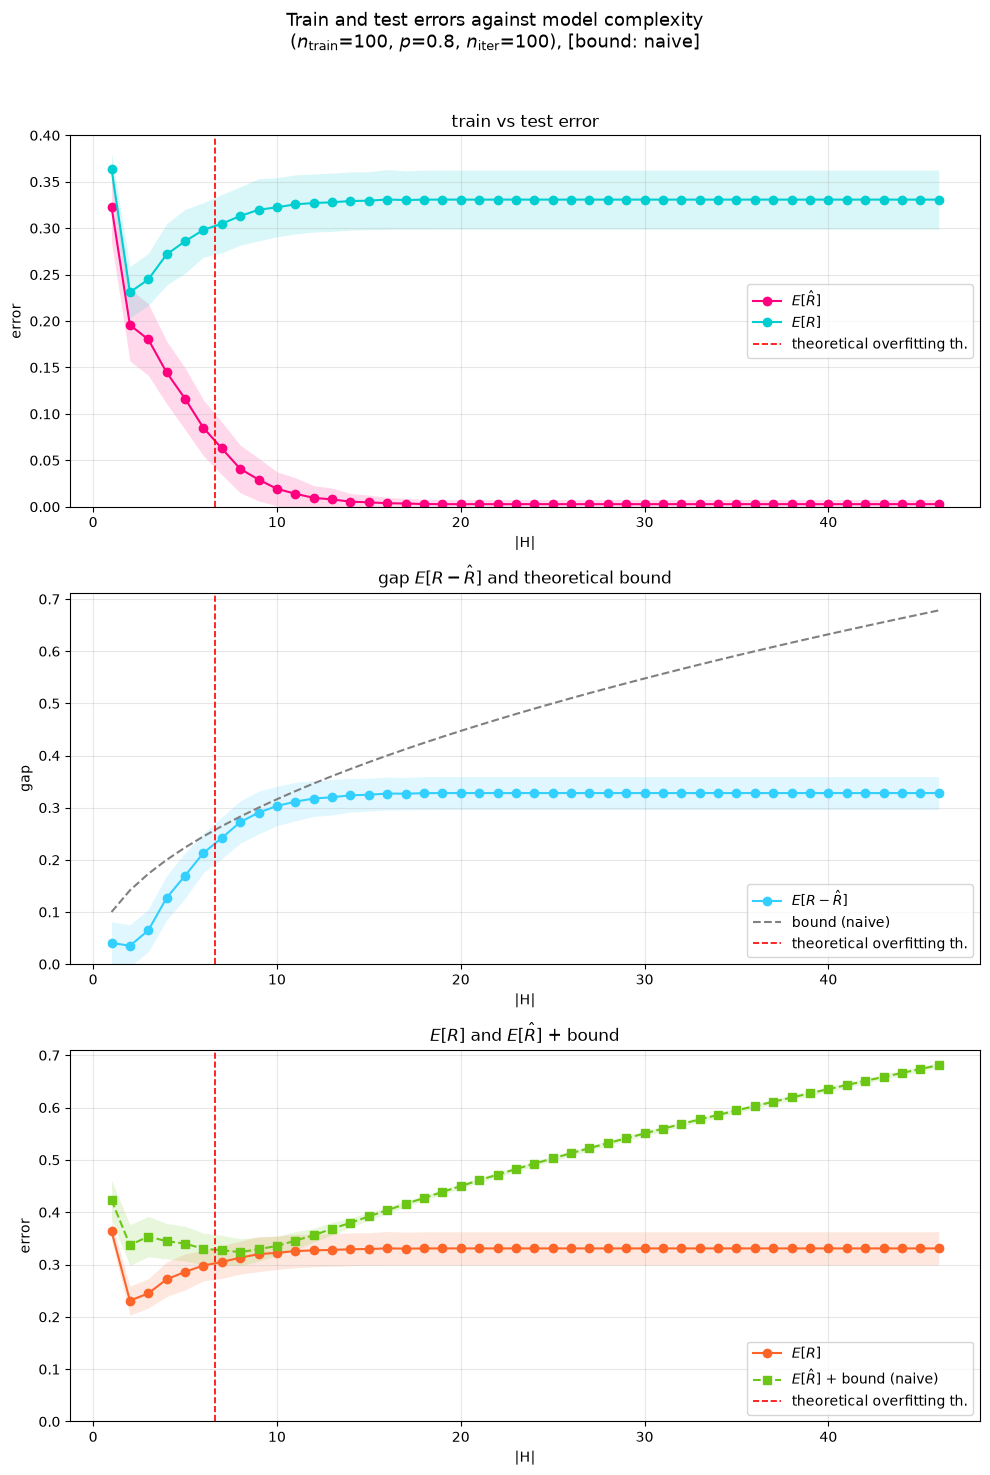

In [5]:
# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 100
prob = 0.8
T = 100

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y_bernoulli(x = x_test, f = centered_parabola, p = prob)

# build models and do plots
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel,
    error_type= 'bernoulli', error_par=prob)
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
      n_train = n, sigma = noise_std, num_iter= T, model = mymodel, 
      bound_name = "naive", bound_params = {},
      error_type='bernoulli', error_par= prob)

la differenza con un errore bernoulliano è solo che abbiamo piu noise difficile da prevedere, ma l'andamento delle curve è lo stesso. 

vediamo allora cosa succede ai dati con diverse noise structures, perché secondo me la differenza di comportamento di cui sopra dipende solo dal num di misclassified inputs


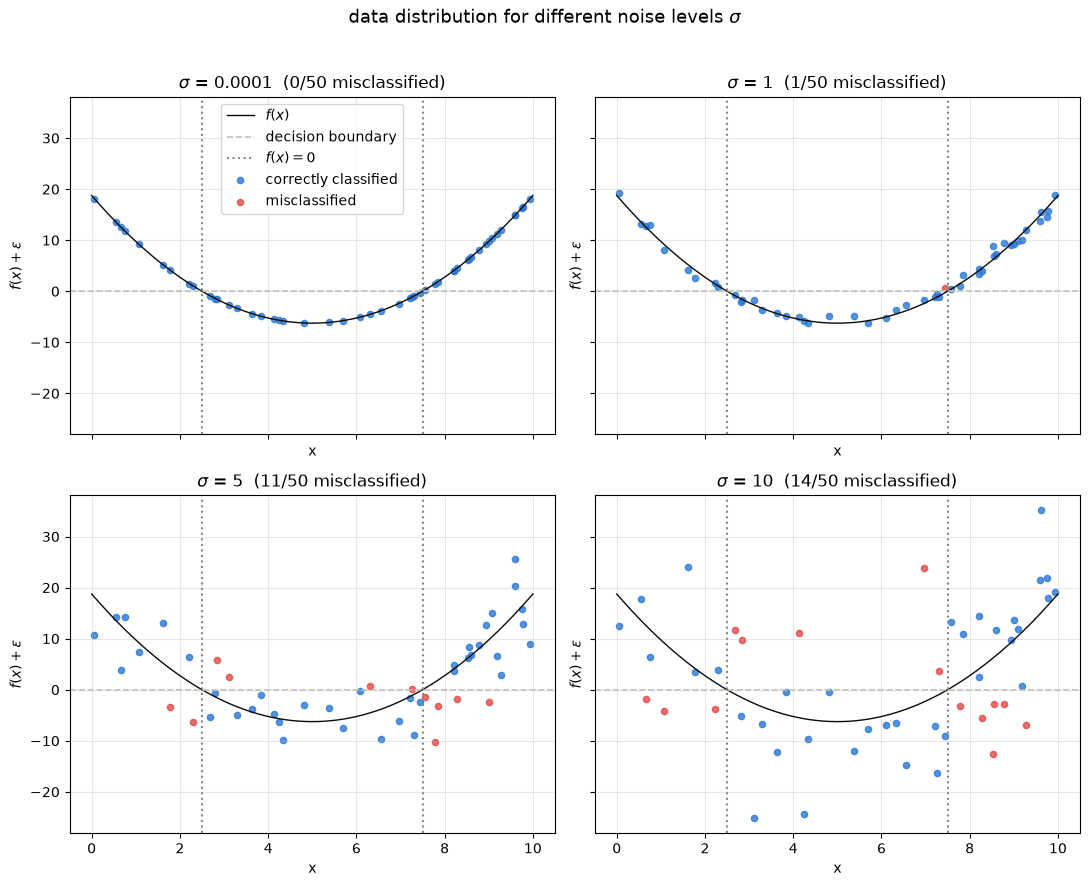

In [6]:
# explore data for gaussian noise
explore_data(fun = centered_parabola, n_train = 50, supp_size = 10_000, sigmas = (10 **(-4), 1, 5, 10))


let's see for which $p$ we get roughly the same misclassified inputs as for $\sigma = 5$.

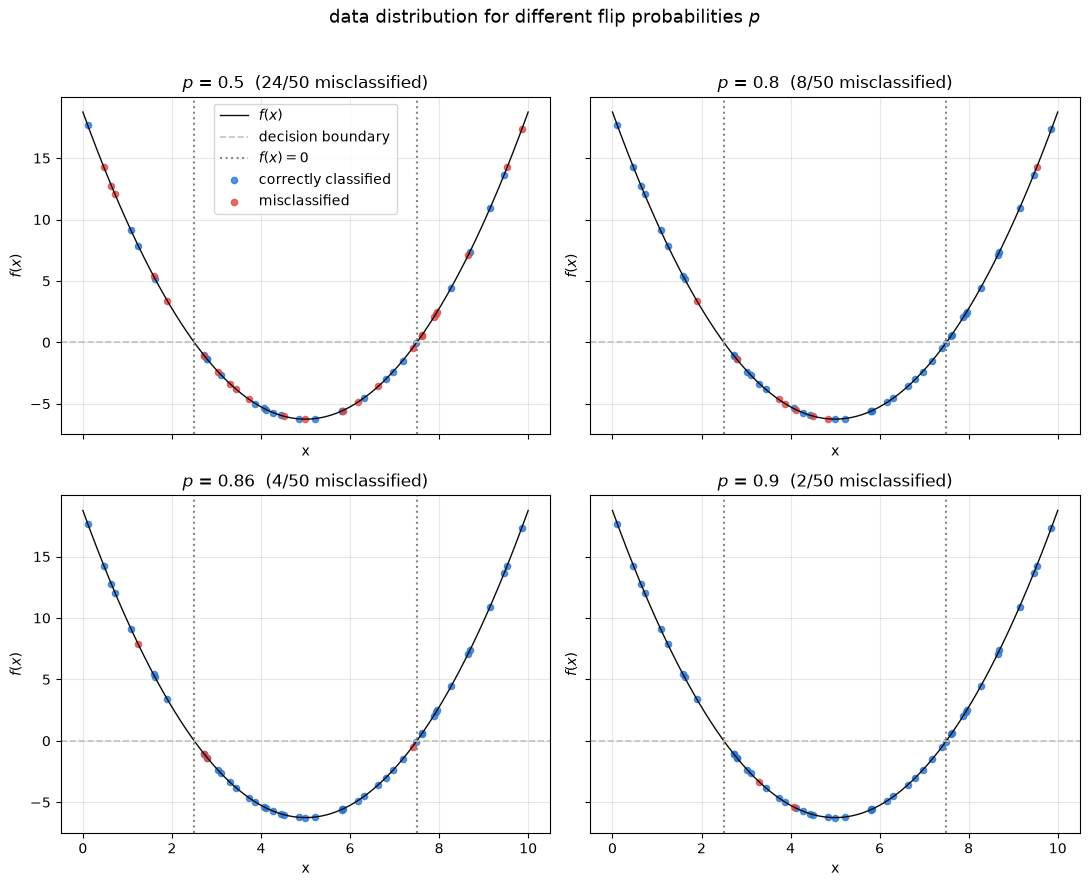

In [7]:
# explore data for bernoulli noise

explore_data(fun = centered_parabola, n_train = 50, supp_size = 10_000, error_type = 'bernoulli', probs = (0.5,0.8,0.86,0.9))


$p = 0.86$ seems to work!

[checkpoint] bound: "naive" -> bound_naive, params: []


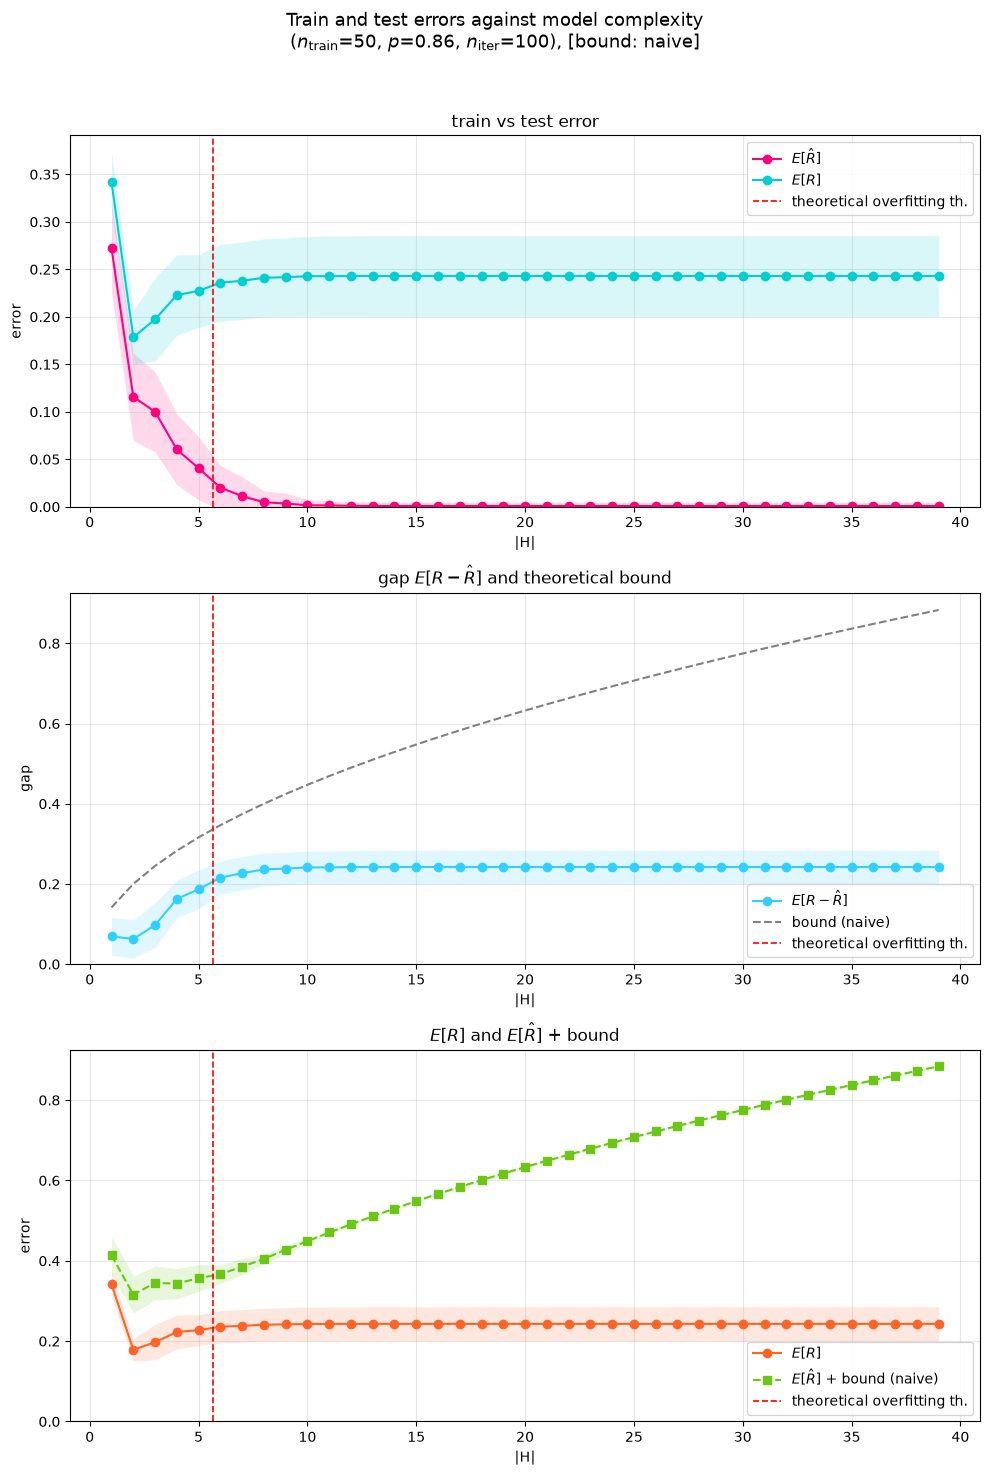

In [8]:
# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 50
prob = 0.86
T = 100

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y_bernoulli(x = x_test, f = centered_parabola, p = prob)

# build models and do plots (put whatever sigma because i never use it)
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(x_test, y_test, n_train = n, num_iter = T, sigma = 1, model = mymodel, error_type= 'bernoulli', error_par=prob)
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, n_train = n, sigma = 1, num_iter= T, model = mymodel, bound_name = "naive", bound_params = {}, error_type='bernoulli', error_par= prob)

[checkpoint] bound: "naive" -> bound_naive, params: []


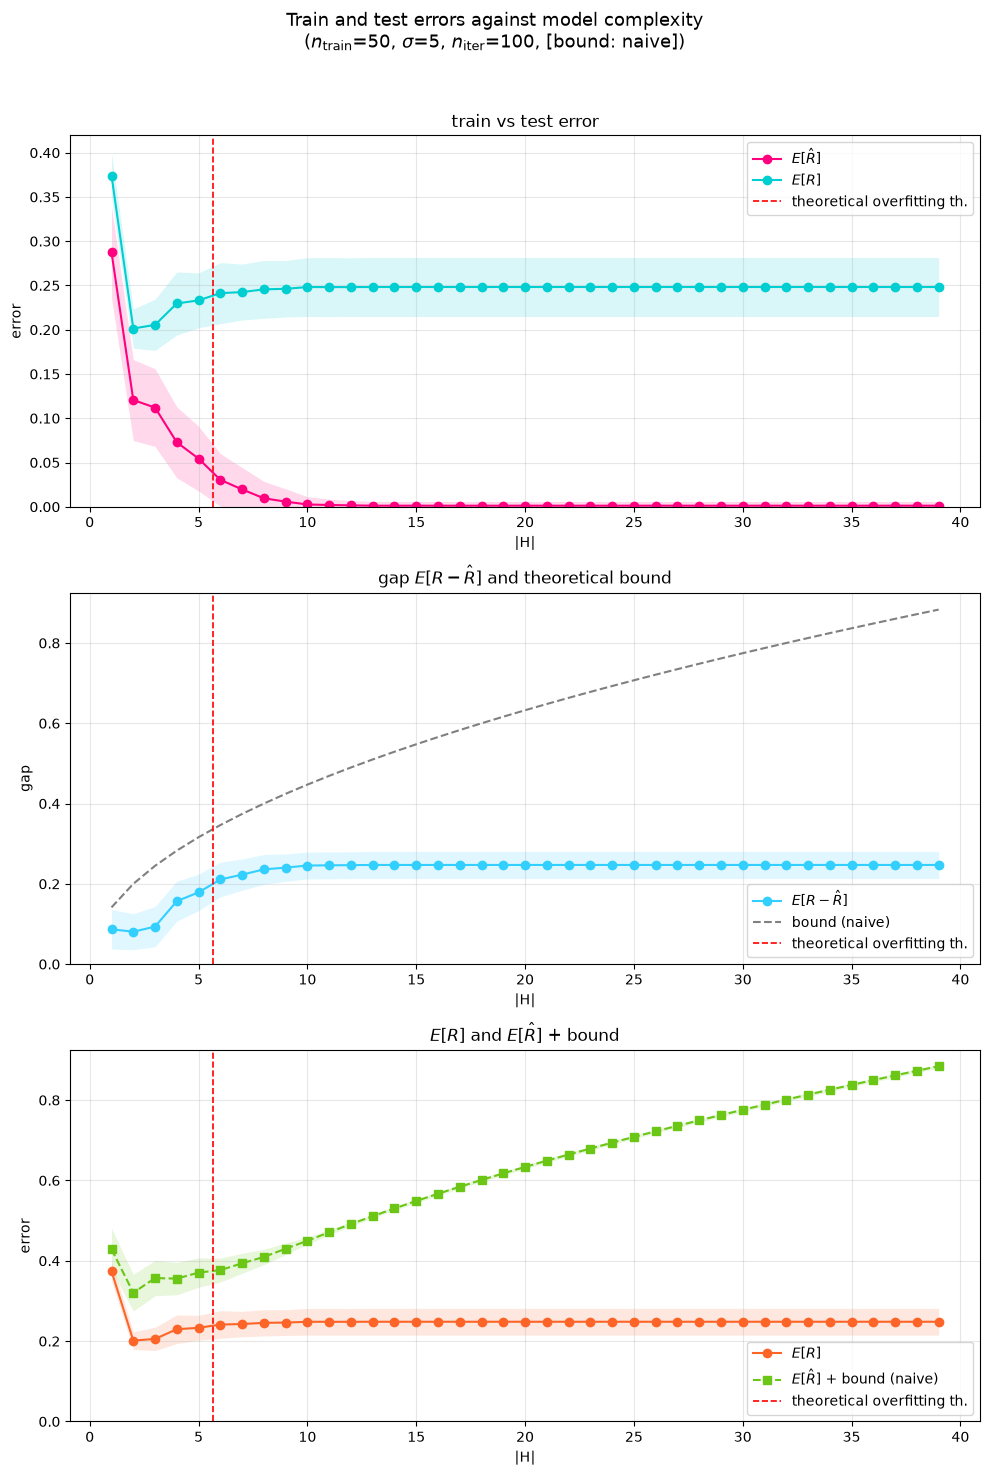

In [9]:
# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 50
noise_std = 5
T = 100

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = centered_parabola, sigma = noise_std)

# build models and do plots
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel)
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, n_train = n, sigma = noise_std, num_iter= T, model = mymodel, bound_name = "naive", bound_params = {})

$\star$ They are essentially equal!!! hehehehhe $\star$